# Visualize AcoustiX Endpoint Panorama Depth Maps

This notebook visualizes the endpoint panorama depth maps generated under `data/acoustix_pair_dataset/box_smoke_pairs`.

Each `depth/point_XXX.npy` file is expected to have AcousticRooms-style equirectangular depth shape `[H, W]`, e.g. `[256, 512]`. The companion `depth/point_XXX_coord.npy` file stores the xRIR-ready camera-coordinate map with shape `[3, H, W]`.

In [12]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "tools":
    REPO_ROOT = REPO_ROOT.parent

DATASET_ROOT = REPO_ROOT / "data" / "acoustix_pair_dataset" / "box_smoke_pairs"
METADATA_PATH = DATASET_ROOT / "metadata.json"
DEPTH_DIR = DATASET_ROOT / "depth"

with METADATA_PATH.open("r", encoding="utf-8") as fin:
    metadata = json.load(fin)

points = np.load(DATASET_ROOT / metadata["points_file"])
orientations = np.load(DATASET_ROOT / metadata["orientations_file"])
depth_files = sorted(path for path in DEPTH_DIR.glob("point_*.npy") if not path.stem.endswith("_coord"))
depth_coord_files = sorted(DEPTH_DIR.glob("point_*_coord.npy"))

print(f"Dataset: {DATASET_ROOT}")
print(f"Scene: {metadata['scene_file']}")
print(f"Points: {points.shape}")
print(f"Orientations: {orientations.shape}")
print(f"Panorama depth files: {len(depth_files)}")
print(f"Coord depth files: {len(depth_coord_files)}")
print(f"First panorama depth shape: {np.load(depth_files[0]).shape if depth_files else 'N/A'}")
print(f"First coord depth shape: {np.load(depth_coord_files[0]).shape if depth_coord_files else 'N/A'}")

Dataset: /home/yixunhu/codespace/xRIR_code/data/acoustix_pair_dataset/box_smoke_pairs
Scene: /home/yixunhu/codespace/AcoustiX/sionna/sionna/rt/scenes/box/box.xml
Points: (4, 3)
Orientations: (4, 3)
Panorama depth files: 4
Coord depth files: 4
First panorama depth shape: (256, 512)
First coord depth shape: (3, 256, 512)


In [13]:
def load_depth(point_idx: int) -> np.ndarray:
    """
    Load one endpoint panorama depth map.

    Parameters
    ----------
    point_idx : int
        Endpoint index to load from `depth/point_XXX.npy`.

    Returns
    -------
    np.ndarray
        Equirectangular panorama depth with shape `[H, W]`.
    """
    depth_path = DEPTH_DIR / f"point_{point_idx:03d}.npy"
    return np.load(depth_path)


def load_depth_coord(point_idx: int) -> np.ndarray:
    """
    Load one xRIR-ready endpoint camera-coordinate depth map.

    Parameters
    ----------
    point_idx : int
        Endpoint index to load from `depth/point_XXX_coord.npy`.

    Returns
    -------
    np.ndarray
        Camera-coordinate map with shape `[3, H, W]`.
    """
    coord_path = DEPTH_DIR / f"point_{point_idx:03d}_coord.npy"
    return np.load(coord_path)


def plot_panorama_depth(point_idx: int, percentile_clip: float = 99.0) -> None:
    """
    Plot one equirectangular endpoint panorama depth map.

    Parameters
    ----------
    point_idx : int
        Endpoint index to visualize.
    percentile_clip : float, optional
        Percentile used as the visualization maximum to avoid one far value
        washing out nearby geometry (default is 99.0).

    Returns
    -------
    None
        Displays a matplotlib figure.
    """
    depth = load_depth(point_idx)
    nonzero_depth = depth[depth > 0]
    vmax = np.percentile(nonzero_depth, percentile_clip) if nonzero_depth.size else 1.0

    fig, axis = plt.subplots(figsize=(12, 5), constrained_layout=True)
    image = axis.imshow(depth, cmap="magma", vmin=0.0, vmax=vmax, aspect="auto")
    axis.set_title(
        f"Point {point_idx:03d} | xyz={np.round(points[point_idx], 3).tolist()} | panorama depth shape={depth.shape}"
    )
    axis.set_xlabel("azimuth / theta pixel")
    axis.set_ylabel("elevation / phi pixel")
    fig.colorbar(image, ax=axis, fraction=0.025, pad=0.02, label="depth [m]")
    plt.show()

    coord = load_depth_coord(point_idx)
    print(f"xRIR-ready coord shape: {coord.shape}")

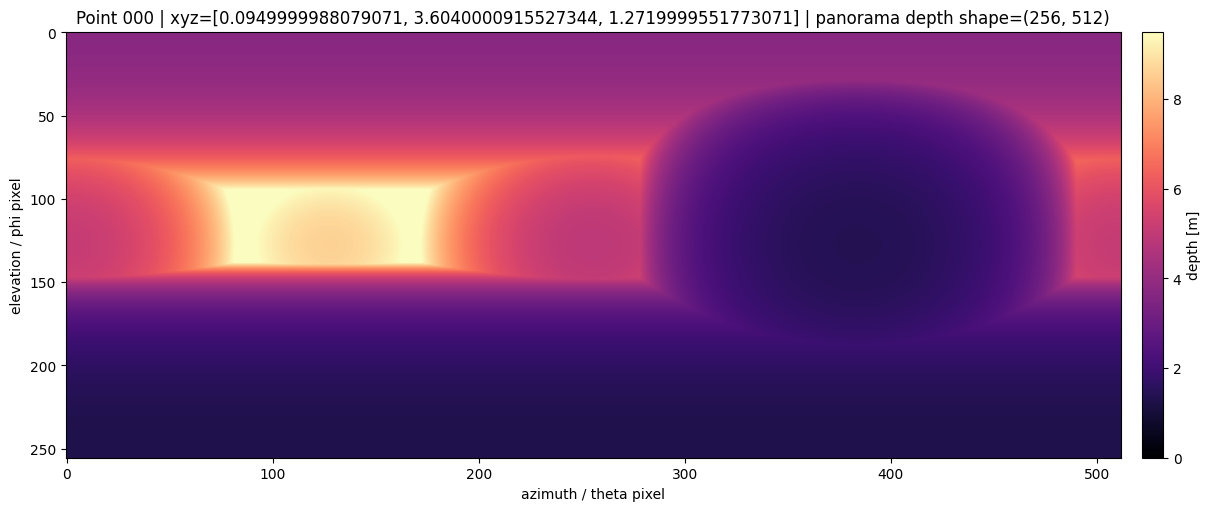

xRIR-ready coord shape: (3, 256, 512)


In [14]:
# Change this index to inspect another endpoint.
plot_panorama_depth(point_idx=0)

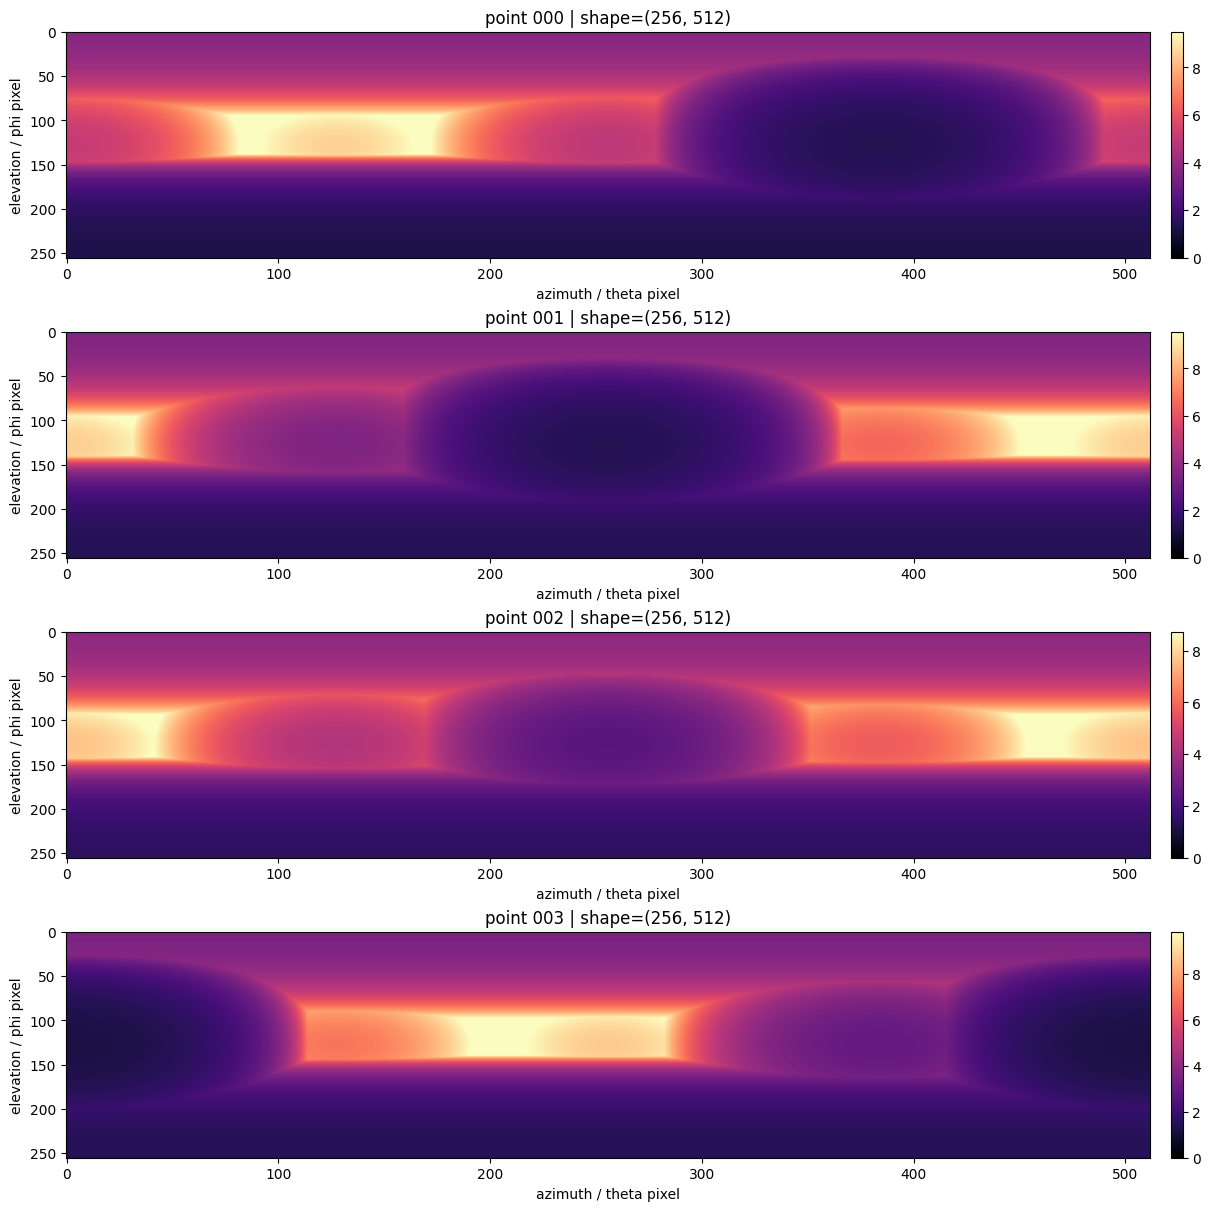

In [15]:
def plot_all_points_overview() -> None:
    """
    Plot a compact overview of every endpoint panorama depth map.

    Parameters
    ----------
    None
        This function takes no parameters.

    Returns
    -------
    None
        Displays a matplotlib figure where each row is one endpoint panorama.
    """
    num_points = len(depth_files)
    fig, axes = plt.subplots(num_points, 1, figsize=(12, 3 * num_points), constrained_layout=True)
    axes = np.asarray(axes).reshape(num_points)

    for point_idx in range(num_points):
        depth = load_depth(point_idx)
        nonzero_depth = depth[depth > 0]
        vmax = np.percentile(nonzero_depth, 99.0) if nonzero_depth.size else 1.0
        axis = axes[point_idx]
        image = axis.imshow(depth, cmap="magma", vmin=0.0, vmax=vmax, aspect="auto")
        axis.set_title(f"point {point_idx:03d} | shape={depth.shape}")
        axis.set_xlabel("azimuth / theta pixel")
        axis.set_ylabel("elevation / phi pixel")
        fig.colorbar(image, ax=axis, fraction=0.025, pad=0.02)

    plt.show()


plot_all_points_overview()

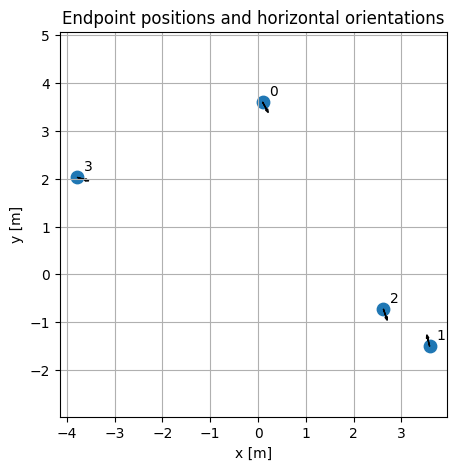

In [16]:
# Optional: visualize endpoint positions in the xy plane.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(points[:, 0], points[:, 1], s=80)
for point_idx, point in enumerate(points):
    ax.annotate(str(point_idx), (point[0], point[1]), textcoords="offset points", xytext=(5, 5))
    ax.arrow(
        point[0],
        point[1],
        orientations[point_idx, 0] * 0.25,
        orientations[point_idx, 1] * 0.25,
        head_width=0.05,
        length_includes_head=True,
    )
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Endpoint positions and horizontal orientations")
ax.axis("equal")
ax.grid(True)
plt.show()

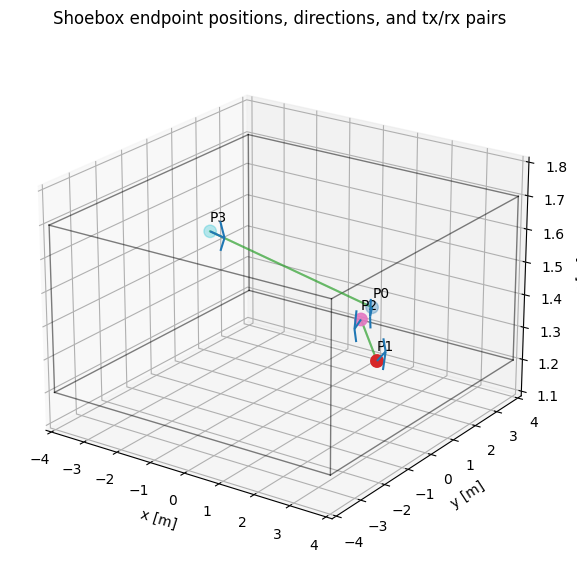

In [17]:
# 3D visualization of endpoint positions and directions inside the shoebox.
# These bounds match the box_smoke_pairs generation command.
SHOEBOX_MIN = np.array([-4.0, -4.0, 1.2])
SHOEBOX_MAX = np.array([4.0, 4.0, 1.7])


def draw_box_edges(axis, xyz_min: np.ndarray, xyz_max: np.ndarray) -> None:
    """
    Draw a wireframe box in a 3D matplotlib axis.

    Parameters
    ----------
    axis : matplotlib.axes.Axes
        3D matplotlib axis to draw on.
    xyz_min : np.ndarray
        Minimum x/y/z corner with shape `(3,)`.
    xyz_max : np.ndarray
        Maximum x/y/z corner with shape `(3,)`.

    Returns
    -------
    None
        The wireframe is drawn in-place.
    """
    x0, y0, z0 = xyz_min
    x1, y1, z1 = xyz_max
    corners = np.array(
        [
            [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0],
            [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1],
        ]
    )
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]
    for start_idx, end_idx in edges:
        start = corners[start_idx]
        end = corners[end_idx]
        axis.plot(
            [start[0], end[0]],
            [start[1], end[1]],
            [start[2], end[2]],
            color="black",
            linewidth=1.0,
            alpha=0.5,
        )


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

draw_box_edges(ax, SHOEBOX_MIN, SHOEBOX_MAX)

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=80, c=np.arange(len(points)), cmap="tab10")
ax.quiver(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    orientations[:, 0],
    orientations[:, 1],
    orientations[:, 2],
    length=0.6,
    normalize=True,
    color="tab:blue",
)

for point_idx, point in enumerate(points):
    ax.text(point[0], point[1], point[2] + 0.03, f"P{point_idx}", fontsize=10)

# Draw valid tx/rx pairs as light gray connection lines.
for pair in metadata["pairs"]:
    tx_point = points[pair["tx_index"]]
    rx_point = points[pair["rx_index"]]
    line_color = "tab:green" if pair["valid"] else "tab:red"
    ax.plot(
        [tx_point[0], rx_point[0]],
        [tx_point[1], rx_point[1]],
        [tx_point[2], rx_point[2]],
        color=line_color,
        linewidth=1.5,
        alpha=0.45,
    )

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Shoebox endpoint positions, directions, and tx/rx pairs")
ax.set_xlim(SHOEBOX_MIN[0], SHOEBOX_MAX[0])
ax.set_ylim(SHOEBOX_MIN[1], SHOEBOX_MAX[1])
ax.set_zlim(SHOEBOX_MIN[2] - 0.1, SHOEBOX_MAX[2] + 0.1)
ax.view_init(elev=22, azim=-55)
plt.show()